In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator


2026-01-07 19:49:03.112308: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767815343.301267      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767815343.352542      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
data_dir = '/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset'
categories = ['Benign cases', 'Malignant cases', 'Normal cases']
num_classes = len(categories)

def load_images(data_dir, img_size=224):
    X, y = [], []

    for cls in categories:
        cls_folder = os.path.join(data_dir, cls)
        for img_file in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, img_file)
            img = cv2.imread(img_path)
            if img is None:
                continue

            # --- CLAHE ---
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            enhanced = clahe.apply(gray)

            # Back to RGB
            img = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
            img = cv2.resize(img, (img_size, img_size))
            img = preprocess_input(img)

            X.append(img)
            y.append(cls)

    X = np.array(X, dtype=np.float32)
    y = LabelEncoder().fit_transform(y)
    y = to_categorical(y, num_classes=num_classes)

    return X, y

X, y = load_images(data_dir)


In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


In [4]:
y_integers = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_integers),
    y=y_integers
)
class_weights = dict(enumerate(class_weights))


In [5]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    shear_range=0.1,
    brightness_range=[0.8, 1.2]
)
datagen.fit(X_train)


In [6]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # Phase 1: Feature extraction

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


I0000 00:00:1767815403.832079      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,768,899 (94.49 MB)

 Trainable params: 1,181,187 (4.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [7]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=100,
    class_weight=class_weights,
    verbose=1
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1767815417.660287      64 service.cc:148] XLA service 0x7b339c003970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767815417.661225      64 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1767815419.170063      64 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/79 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.3594 - loss: 2.1062  

I0000 00:00:1767815422.667082      64 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


79/79 ━━━━━━━━━━━━━━━━━━━━ 55s 512ms/step - accuracy: 0.5822 - loss: 1.0689 - val_accuracy: 0.7320 - val_loss: 0.5162
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 368ms/step - accuracy: 0.7966 - loss: 0.4506 - val_accuracy: 0.7985 - val_loss: 0.4491
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 372ms/step - accuracy: 0.8130 - loss: 0.3899 - val_accuracy: 0.8429 - val_loss: 0.3338
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 367ms/step - accuracy: 0.8274 - loss: 0.3708 - val_accuracy: 0.8577 - val_loss: 0.3128
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 369ms/step - accuracy: 0.8533 - loss: 0.3301 - val_accuracy: 0.8392 - val_loss: 0.3668
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 368ms/step - accuracy: 0.8488 - loss: 0.3406 - val_accuracy: 0.8817 - val_loss: 0.2800
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 369ms/step - accuracy: 0.8862 - loss: 0.2504 - val_accuracy: 0.8484 - val_loss: 0.3313
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 373ms/step - accuracy: 0.8922 - loss: 0.2411 - val_accuracy

In [8]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")


Train Accuracy: 99.25%
Validation Accuracy: 97.41%
Test Accuracy: 96.31%


17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 329ms/step
Classification Report:

                 precision    recall  f1-score   support

   Benign cases       0.95      0.94      0.94       180
Malignant cases       1.00      1.00      1.00       180
   Normal cases       0.94      0.95      0.95       182

       accuracy                           0.96       542
      macro avg       0.96      0.96      0.96       542
   weighted avg       0.96      0.96      0.96       542



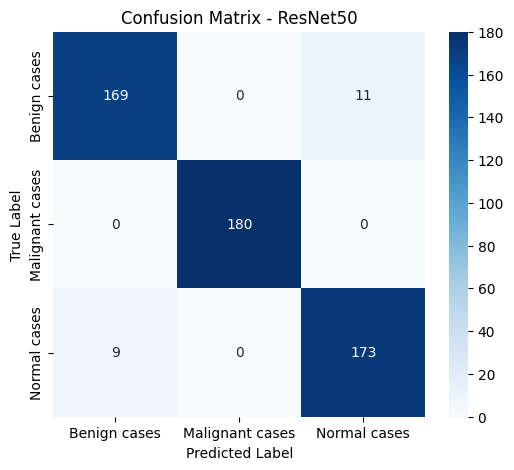

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=categories))

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=categories,
    yticklabels=categories
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ResNet50")
plt.show()


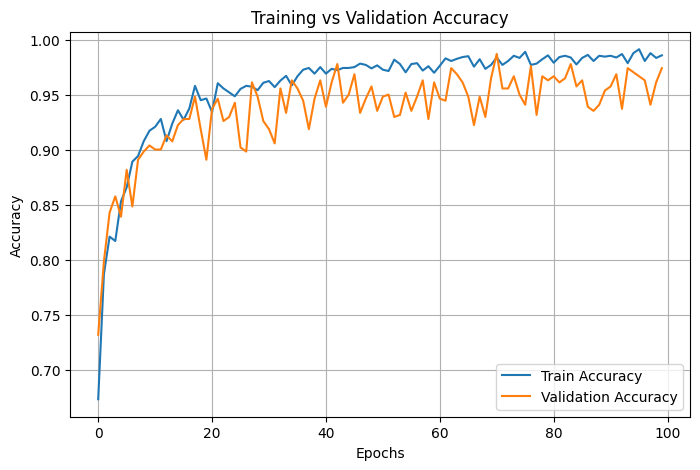

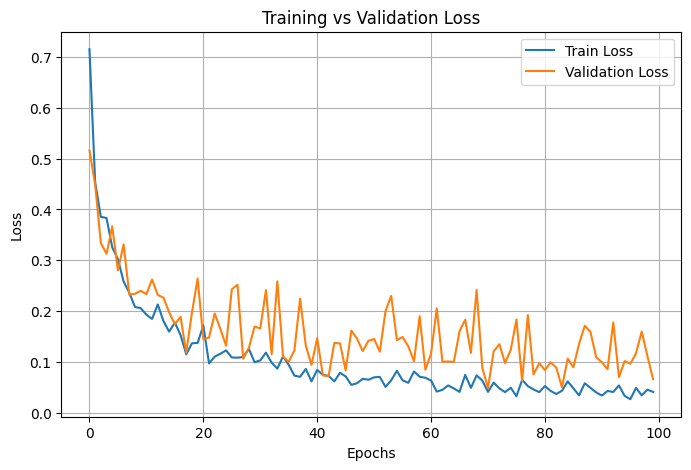

In [10]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()



17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


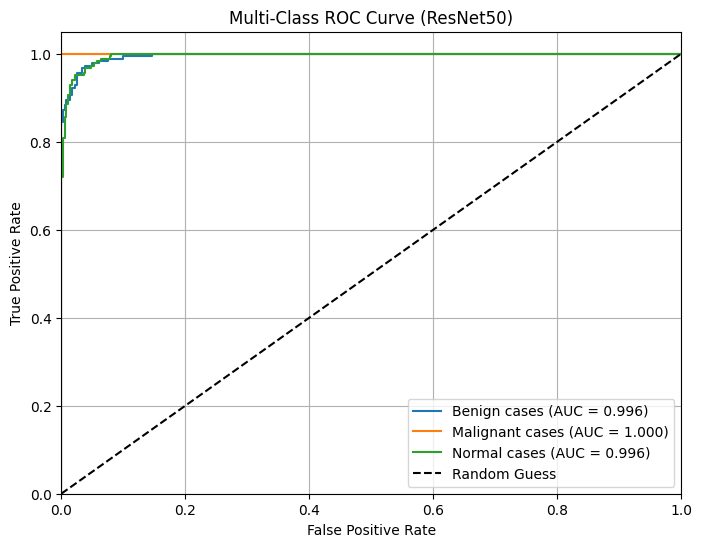

In [11]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Predict probabilities
y_pred_prob = model.predict(X_test)

# True labels
y_true = np.argmax(y_test, axis=1)

# Binarize labels for ROC
y_test_bin = label_binarize(y_true, classes=[0, 1, 2])

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))

for i in range(num_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{categories[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve (ResNet50)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import numpy as np
import tensorflow as tf


In [13]:
y_labels = np.argmax(y, axis=1)
num_classes = y.shape[1]


In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
val_accuracies = []
val_losses = []


In [15]:
for train_idx, val_idx in skf.split(X, y_labels):

    print("\n===================================")
    print(f"Training Fold {fold}")
    print("===================================")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # ---- Class Weights ----
    y_int = np.argmax(y_train, axis=1)
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_int),
        y=y_int
    )
    class_weights = dict(enumerate(class_weights))

    # ---- Data Augmentation ----
    datagen = ImageDataGenerator(
        rotation_range=20,
        zoom_range=0.15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        shear_range=0.1,
        brightness_range=[0.8, 1.2]
    )
    datagen.fit(X_train)

    # ---- Build ResNet50 Model (NEW each fold) ----
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # ---- Train ----
    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=32),
        validation_data=(X_val, y_val),
        epochs=50,
        class_weight=class_weights,
        verbose=1
    )

    # ---- Evaluate ----
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Fold {fold} Validation Accuracy: {val_acc*100:.2f}%")

    fold += 1



Training Fold 1


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 56s 477ms/step - accuracy: 0.5528 - loss: 1.1197 - val_accuracy: 0.7535 - val_loss: 0.4942
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 378ms/step - accuracy: 0.7767 - loss: 0.4641 - val_accuracy: 0.7839 - val_loss: 0.4395
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 35s 379ms/step - accuracy: 0.8242 - loss: 0.3952 - val_accuracy: 0.7950 - val_loss: 0.4321
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 376ms/step - accuracy: 0.8540 - loss: 0.3468 - val_accuracy: 0.8601 - val_loss: 0.3185
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 376ms/step - accuracy: 0.8688 - loss: 0.2954 - val_accuracy: 0.8712 - val_loss: 0.2707
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 373ms/step - accuracy: 0.8808 - loss: 0.2750 - val_accuracy: 0.8573 - val_loss: 0.3355
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 371ms/step - accuracy: 0.8858 - loss: 0.2646 - val_accuracy: 0.8463 - val_loss: 0.3375
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 370ms/step - accuracy: 0.9067 - loss: 0.2224 - val_accu

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 55s 462ms/step - accuracy: 0.6134 - loss: 0.9798 - val_accuracy: 0.7950 - val_loss: 0.4365
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 371ms/step - accuracy: 0.7758 - loss: 0.4748 - val_accuracy: 0.8324 - val_loss: 0.3837
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 372ms/step - accuracy: 0.8367 - loss: 0.3609 - val_accuracy: 0.8546 - val_loss: 0.3214
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 374ms/step - accuracy: 0.8405 - loss: 0.3583 - val_accuracy: 0.8546 - val_loss: 0.3078
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 370ms/step - accuracy: 0.8676 - loss: 0.2996 - val_accuracy: 0.8643 - val_loss: 0.2814
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 374ms/step - accuracy: 0.8846 - loss: 0.2619 - val_accuracy: 0.8657 - val_loss: 0.2779
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 376ms/step - accuracy: 0.8942 - loss: 0.2537 - val_accuracy: 0.8795 - val_loss: 0.2666
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 371ms/step - accuracy: 0.8953 - loss: 0.2304 - val_accu

...

Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 55s 459ms/step - accuracy: 0.6034 - loss: 1.0753 - val_accuracy: 0.7188 - val_loss: 0.5755
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 369ms/step - accuracy: 0.7733 - loss: 0.4762 - val_accuracy: 0.7604 - val_loss: 0.4534
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 370ms/step - accuracy: 0.8145 - loss: 0.3868 - val_accuracy: 0.7964 - val_loss: 0.3989
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 368ms/step - accuracy: 0.8401 - loss: 0.3424 - val_accuracy: 0.8435 - val_loss: 0.3375
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 372ms/step - accuracy: 0.8647 - loss: 0.3100 - val_accuracy: 0.8850 - val_loss: 0.2514
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 376ms/step - accuracy: 0.8433 - loss: 0.3299 - val_accuracy: 0.9017 - val_loss: 0.2541
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 377ms/step - accuracy: 0.8854 - loss: 0.2655 - val_accuracy: 0.8975 - val_loss: 0.2282
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 379ms/step - accuracy: 0.8890 - loss: 0.2679 - val_accu

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 56s 474ms/step - accuracy: 0.6002 - loss: 0.9802 - val_accuracy: 0.7978 - val_loss: 0.4143
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 375ms/step - accuracy: 0.7428 - loss: 0.4961 - val_accuracy: 0.8241 - val_loss: 0.3705
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 374ms/step - accuracy: 0.8440 - loss: 0.3577 - val_accuracy: 0.8338 - val_loss: 0.3522
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 35s 384ms/step - accuracy: 0.8344 - loss: 0.3667 - val_accuracy: 0.7812 - val_loss: 0.4283
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 378ms/step - accuracy: 0.8402 - loss: 0.3427 - val_accuracy: 0.8338 - val_loss: 0.3784
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 372ms/step - accuracy: 0.8610 - loss: 0.3218 - val_accuracy: 0.8518 - val_loss: 0.3056
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 373ms/step - accuracy: 0.8895 - loss: 0.2670 - val_accuracy: 0.8435 - val_loss: 0.3229
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 375ms/step - accuracy: 0.9031 - loss: 0.2345 - val_accu

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 55s 479ms/step - accuracy: 0.5615 - loss: 1.2282 - val_accuracy: 0.8044 - val_loss: 0.4355
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 33s 367ms/step - accuracy: 0.7854 - loss: 0.4512 - val_accuracy: 0.7531 - val_loss: 0.4473
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 33s 364ms/step - accuracy: 0.8222 - loss: 0.3816 - val_accuracy: 0.8377 - val_loss: 0.3709
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 33s 363ms/step - accuracy: 0.8489 - loss: 0.3578 - val_accuracy: 0.8516 - val_loss: 0.3100
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 33s 363ms/step - accuracy: 0.8635 - loss: 0.2986 - val_accuracy: 0.8474 - val_loss: 0.3525
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 33s 364ms/step - accuracy: 0.8810 - loss: 0.2771 - val_accuracy: 0.8627 - val_loss: 0.3102
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 33s 365ms/step - accuracy: 0.8892 - loss: 0.2553 - val_accuracy: 0.8904 - val_loss: 0.2648
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 33s 367ms/step - accuracy: 0.9017 - loss: 0.2298 - val_accu

In [16]:
print("\n===================================")
print("Stratified K-Fold Cross Validation")
print("===================================")
print(f"Mean Validation Accuracy: {np.mean(val_accuracies)*100:.2f}%")
print(f"Std Validation Accuracy: {np.std(val_accuracies)*100:.2f}%")
print(f"Mean Validation Loss: {np.mean(val_losses):.4f}")



Stratified K-Fold Cross Validation
Mean Validation Accuracy: 94.90%
Std Validation Accuracy: 1.46%
Mean Validation Loss: 0.1376


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1086']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


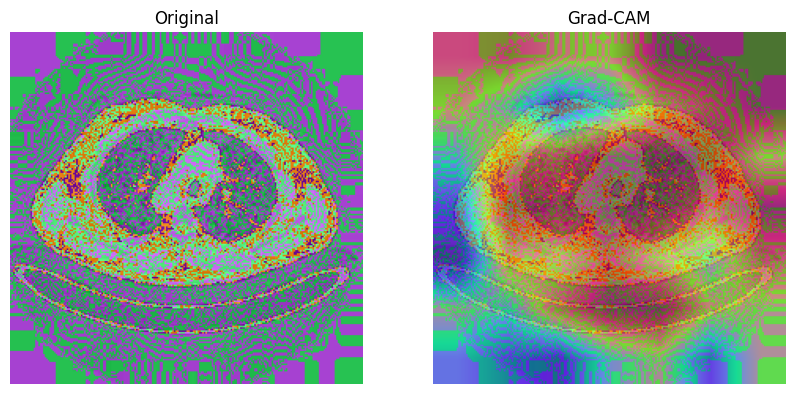

In [17]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# -------------------------
# Model Setup
# -------------------------
input_shape = (224, 224, 3)
num_classes = 3

# Input
inputs = layers.Input(shape=input_shape)

# Base model
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=inputs)
base_model.trainable = False

# Top layers
x = layers.Flatten()(base_model.output)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Functional model
model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# -------------------------
# Grad-CAM Function
# -------------------------
def get_gradcam(model, img_array, class_index=None):
    # Find last conv layer
    last_conv_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            last_conv_layer = layer
            break
    if last_conv_layer is None:
        raise ValueError("No conv layer found in the model.")

    # Grad-CAM model
    grad_model = Model(
        inputs=model.inputs,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if class_index is None:
            class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8
    return heatmap

# -------------------------
# Overlay Function
# -------------------------
def overlay_gradcam(img, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, colormap)
    overlayed = cv2.addWeighted(img, 1-alpha, heatmap_color, alpha, 0)
    return overlayed

# -------------------------
# Example usage
# -------------------------
idx = 10
test_img = X_test[idx]  # your preprocessed test image
original_img = ((test_img + 1) * 127.5).astype(np.uint8)  # convert back to uint8
input_img = np.expand_dims(test_img, axis=0)

# Preprocess input for ResNet50
input_img = preprocess_input(input_img.astype(np.float32))

heatmap = get_gradcam(model, input_img)
overlay_img = overlay_gradcam(original_img, heatmap)

# Display
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_img)
plt.axis('off')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(overlay_img)
plt.axis('off')
plt.title('Grad-CAM')
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1265']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


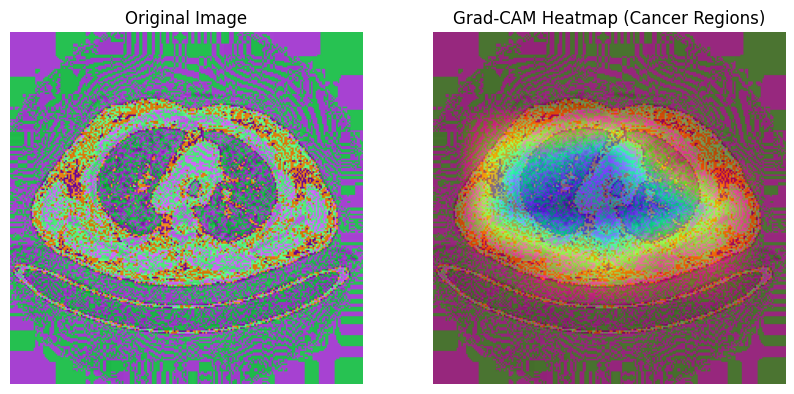

In [18]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# -------------------------
# Model Setup
# -------------------------
input_shape = (224, 224, 3)
num_classes = 3

inputs = layers.Input(shape=input_shape)
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=inputs)
base_model.trainable = False

x = layers.Flatten()(base_model.output)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# -------------------------
# Grad-CAM Function
# -------------------------
def get_gradcam(model, img_array, class_index=None):
    # Last conv layer
    last_conv_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            last_conv_layer = layer
            break
    if last_conv_layer is None:
        raise ValueError("No conv layer found in the model.")

    grad_model = Model(
        inputs=model.inputs,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if class_index is None:
            class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8
    return heatmap  # no .numpy() here

# -------------------------
# Overlay Grad-CAM on image
# -------------------------
def overlay_gradcam(img, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, colormap)
    overlayed = cv2.addWeighted(img, 1-alpha, heatmap_color, alpha, 0)
    return overlayed

# -------------------------
# Example usage
# -------------------------
idx = 10  # choose an image index
test_img = X_test[idx]  # preprocessed image, shape (224,224,3)
original_img = ((test_img + 1) * 127.5).astype(np.uint8)  # convert back to uint8

input_img = np.expand_dims(test_img, axis=0)
input_img = preprocess_input(input_img.astype(np.float32))

# Grad-CAM
heatmap = get_gradcam(model, input_img)
overlay_img = overlay_gradcam(original_img, heatmap)

# Display
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_img)
plt.axis('off')
plt.title('Original Image')

plt.subplot(1,2,2)
plt.imshow(overlay_img)
plt.axis('off')
plt.title('Grad-CAM Heatmap (Cancer Regions)')
plt.show()
